# 🎓 Retail Sales Forecasting: The Master Tutorial (From Scratch)

This notebook provides an end-to-end walkthrough of the project, including data processing, **Expert EDA**, and the **COMPLETE** implementation of **5 custom machine learning algorithms** built from the ground up.

---

## 1. 📂 Step 1: Library Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add path for src
sys.path.append('..')
from src.data_preprocessing import merge_datasets, clean_data
from src.feature_engineering import extract_features

%matplotlib inline
sns.set(style="whitegrid", palette="muted")

## 2. 🧹 Step 2: Data Cleaning & Preprocessing

In [2]:
# Prepare datasets
df_raw = merge_datasets('../data')
df = clean_data(df_raw)
df = extract_features(df)

print(f"Dataset ready. Total rows: {len(df)}")

2026-04-09 23:04:28,290 - src.utils - INFO - Detected datasets: {'train': '../data/train.csv', 'features': '../data/features.csv', 'stores': '../data/stores.csv'}
2026-04-09 23:04:28,299 - src.utils - INFO - Loaded ../data/train.csv with shape (2145, 5)
2026-04-09 23:04:28,302 - src.utils - INFO - Loaded ../data/stores.csv with shape (5, 3)
2026-04-09 23:04:28,305 - src.utils - INFO - Loaded ../data/features.csv with shape (715, 9)
2026-04-09 23:04:28,306 - src.data_preprocessing - INFO - Merging datasets...
2026-04-09 23:04:28,318 - src.data_preprocessing - INFO - Cleaning data...
2026-04-09 23:04:28,327 - src.data_preprocessing - INFO - Cleaning complete. Shape: (2145, 13)
2026-04-09 23:04:28,328 - src.feature_engineering - INFO - Extracting features...
2026-04-09 23:04:28,334 - src.feature_engineering - INFO - Feature extraction complete.


Dataset ready. Total rows: 2145


In [4]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,CPI,Unemployment,Year,Month,Day,DayOfWeek,Is_Weekend,Quarter,WeekOfYear
0,1,1,2010-02-05,50168.437578,True,C,176867,54.443667,3.167417,0.000000,282.057895,192.199877,9.631316,2010,2,5,4,0,1,5
1,1,1,2010-02-12,54473.498579,True,C,176867,94.415867,3.734963,70.663052,0.000000,172.477466,6.399166,2010,2,12,4,0,1,6
2,1,1,2010-02-19,33734.413670,False,C,176867,93.031664,2.965543,0.000000,1912.309956,218.323089,6.800577,2010,2,19,4,0,1,7
3,1,1,2010-02-26,36689.795558,False,C,176867,71.023065,3.400999,0.000000,2816.441089,158.541650,4.095798,2010,2,26,4,0,1,8
4,1,1,2010-03-05,43188.160063,False,C,176867,38.076910,3.866527,8331.949117,0.000000,159.106061,5.093417,2010,3,5,4,0,1,9


## 3. 📊 Step 3: Expert Exploratory Data Analysis (EDA)

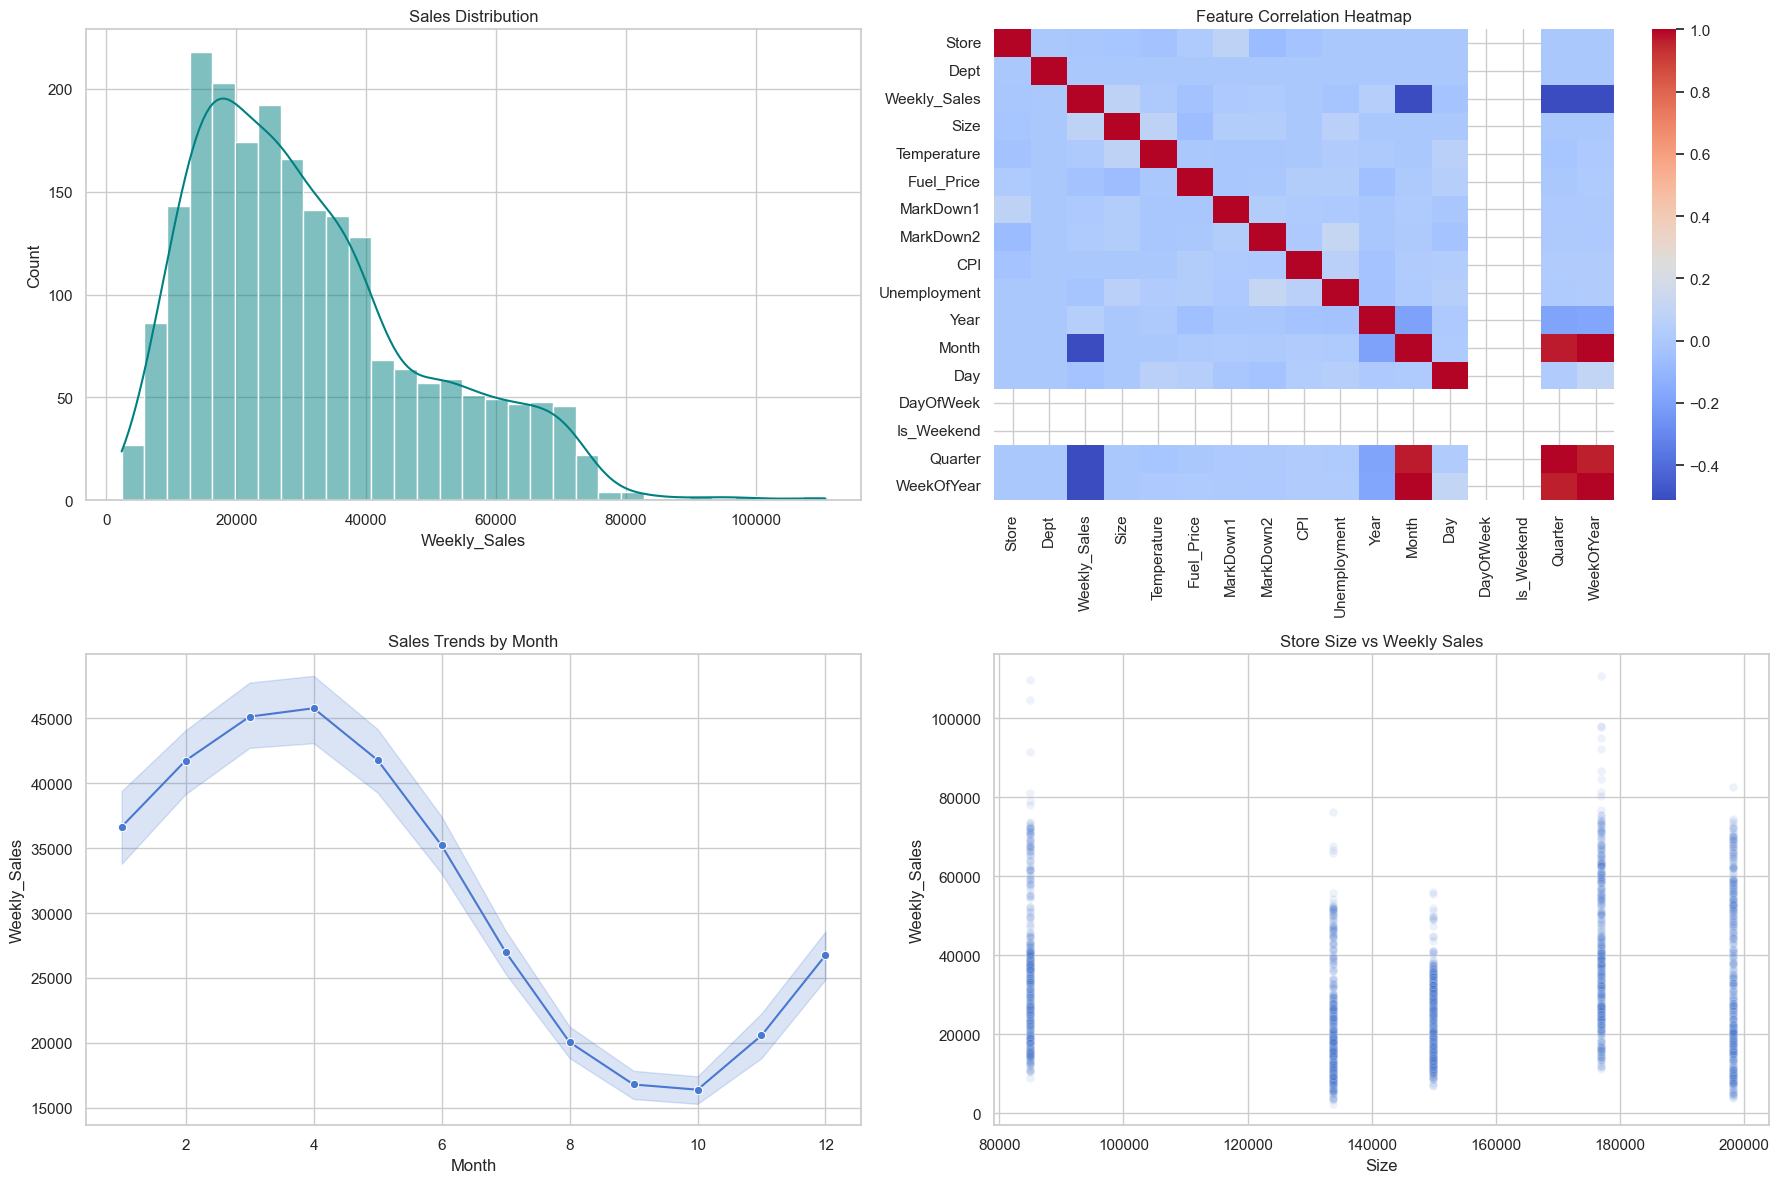

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Target Distribution
sns.histplot(df['Weekly_Sales'], kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Sales Distribution')

# 2. Correlation Map
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Feature Correlation Heatmap')

# 3. Seasonality (Monthly Trends)
sns.lineplot(x='Month', y='Weekly_Sales', data=df, ax=axes[1,0], marker='o')
axes[1,0].set_title('Sales Trends by Month')

# 4. Economic Driver: Size vs Sales
sns.scatterplot(x='Size', y='Weekly_Sales', data=df, alpha=0.1, ax=axes[1,1])
axes[1,1].set_title('Store Size vs Weekly Sales')

plt.tight_layout()
plt.show()

## 4. 🧠 Step 4: From-Scratch Algorithm implementations

### 4.1 Custom Linear Regression
with **Regularization** L2

In [6]:
class CustomLR:
    def __init__(self, lr=0.001, iters=1000, l2=0.01, tol=1e-7):
        self.lr, self.iters, self.l2, self.tol = lr, iters, l2, tol
        self.w, self.b, self.hist = None, None, []

    def fit(self, X, y):
        n, f = X.shape
        self.w, self.b = np.zeros(f), 0
        for i in range(self.iters):
            p = np.dot(X, self.w) + self.b
            cost = (1/(2*n)) * (np.sum((p - y)**2) + self.l2 * np.sum(self.w**2))
            if i > 0 and abs(self.hist[-1] - cost) < self.tol:
                print(f"Converged at epoch {i}"); break
            self.hist.append(cost)
            dw = (1/n) * (np.dot(X.T, (p - y)) + self.l2 * self.w)
            self.w -= self.lr * dw
            self.b -= self.lr * (1/n) * np.sum(p - y)

    def predict(self, X): return np.dot(X, self.w) + self.b

### 4.2 Custom Polynomial Regression

In [ ]:
class CustomPoly:
    def __init__(self, degree=2, lr=0.000001, iters=1000, l2=0.01):
        self.deg, self.lr, self.iters, self.l2 = degree, lr, iters, l2
        self.lr_model = CustomLR(lr=self.lr, iters=self.iters, l2=self.l2)
    def _transform(self, X):
        out = X.copy()
        for d in range(2, self.deg + 1): out = np.hstack([out, np.power(X, d)])
        return out
    def fit(self, X, y): self.lr_model.fit(self._transform(X), y)
    def predict(self, X): return self.lr_model.predict(self._transform(X))

### 4.3 Custom Decision Tree & Random Forest

In [ ]:
class Node:
    def __init__(self, f_idx=None, th=None, l=None, r=None, v=None):
        self.f_idx, self.th, self.l, self.r, self.v = f_idx, th, l, r, v

class CustomDT:
    def __init__(self, max_d=5):
        self.max_d, self.root = max_d, None
    def _grow(self, X, y, d=0):
        n, f = X.shape
        if d >= self.max_d or n < 2 or np.var(y) == 0: return Node(v=np.mean(y))
        b_mse, b_idx, b_th = float("inf"), None, None
        for i in range(f):
            for t in np.unique(X[:, i]):
                l_m, r_m = X[:, i] <= t, X[:, i] > t
                if not np.any(l_m) or not np.any(r_m): continue
                mse = (np.var(y[l_m])*np.sum(l_m) + np.var(y[r_m])*np.sum(r_m)) / n
                if mse < b_mse: b_mse, b_idx, b_th = mse, i, t
        if b_idx is None: return Node(v=np.mean(y))
        l = self._grow(X[X[:, b_idx] <= b_th], y[X[:, b_idx] <= b_th], d + 1)
        r = self._grow(X[X[:, b_idx] > b_th], y[X[:, b_idx] > b_th], d + 1)
        return Node(f_idx=b_idx, th=b_th, l=l, r=r)
    def fit(self, X, y): self.root = self._grow(X, y)
    def _p_one(self, x, node):
        if node.v is not None: return node.v
        return self._p_one(x, node.l) if x[node.f_idx] <= node.th else self._p_one(x, node.r)
    def predict(self, X): return np.array([self._p_one(x, self.root) for x in X])

class CustomRF:
    def __init__(self, n_t=5, max_d=5):
        self.n_t, self.max_d, self.trees = n_t, max_d, []
    def fit(self, X, y):
        for _ in range(self.n_t):
            idx = np.random.choice(len(X), len(X), replace=True)
            t = CustomDT(max_d=self.max_d); t.fit(X[idx], y[idx]); self.trees.append(t)
    def predict(self, X): return np.mean([t.predict(X) for t in self.trees], axis=0)

### 4.4 Custom Gradient Boosting (XGBoost Soul)

In [ ]:
class CustomGB:
    def __init__(self, lr=0.1, n_t=5, max_d=3):
        self.lr, self.n_t, self.max_d = lr, n_t, max_d
        self.trees, self.init_v = [], 0
    def fit(self, X, y):
        self.init_v = np.mean(y); curr_p = np.full(y.shape, self.init_v)
        for _ in range(self.n_t):
            t = CustomDT(max_d=self.max_d); t.fit(X, y - curr_p)
            curr_p += self.lr * t.predict(X); self.trees.append(t)
    def predict(self, X):
        y_p = np.full(X.shape[0], self.init_v)
        for t in self.trees: y_p += self.lr * t.predict(X)
        return y_p